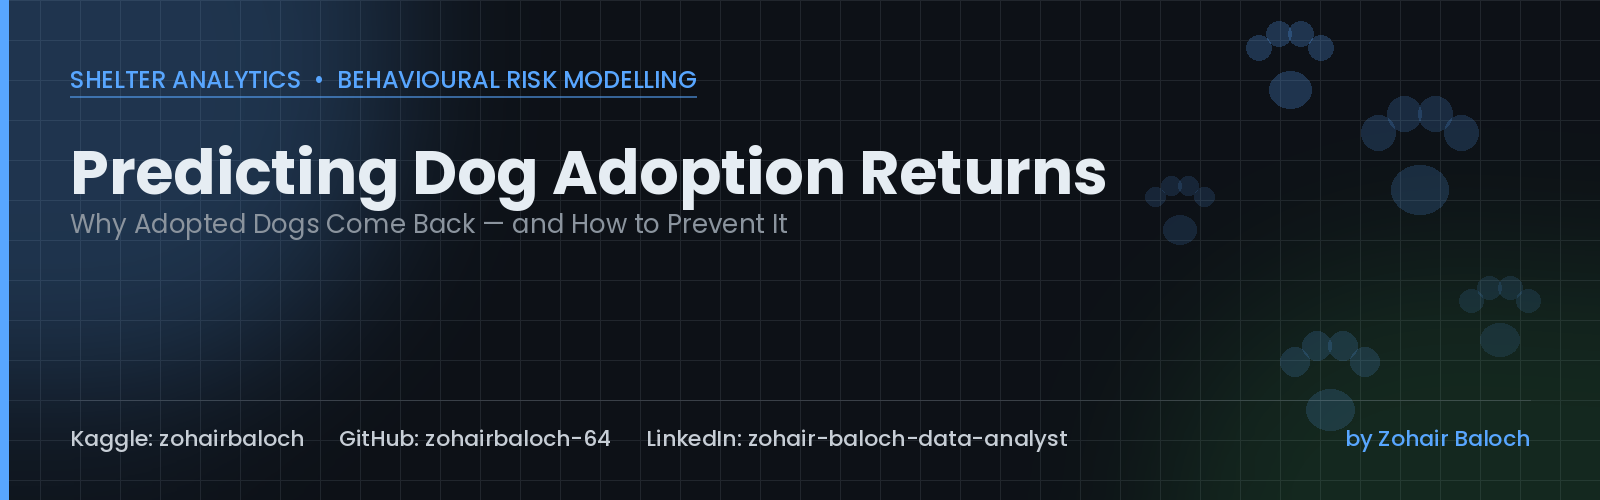

# 🐾 Predicting Dog Adoption Returns
### A Behavioural Risk & Shelter Analytics Case Study

**Author:** Zohair Baloch
**Kaggle:** zohairbaloch &nbsp;|&nbsp; **GitHub:** zohairbaloch-64 &nbsp;|&nbsp; **LinkedIn:** zohair-baloch-data-analyst

---

> Roughly 1 in 6 shelter dogs in this dataset is eventually returned. Every return is a dog re-entering the system, a shelter kennel occupied for longer, and a family experience that ended in disappointment. This notebook builds an end-to-end analytics pipeline — from raw intake and behavioural data to a validated, explainable risk model — to answer one question: **can we flag a risky match *before* it happens?**

## 📋 Project Overview

**Dataset:** 42,000 dog adoption records from a shelter network, spanning intake details, shelter behavioural assessments, adopter household profile, and the final outcome (kept vs. returned).

**Business context:** Shelters run behavioural assessments and pre-adoption counselling, but resources are limited. If we can score *risk of return* at the point of matching, staff can focus extra counselling, trial visits, and follow-up on the adoptions that need it most — instead of treating every match the same.

**What this notebook does:**
- Audits data quality and documents every judgment call made
- Explores the behavioural, household, and process factors linked to returns
- Benchmarks multiple classification models to predict `returned`
- Explains the winning model with SHAP so the "why" is as useful as the "who"
- Translates findings into concrete, shelter-level recommendations

## 🧭 Framework: PACE

This analysis follows the **PACE** framework end to end:

| Stage | Focus |
|---|---|
| **P**lan | Define the business task, stakeholders, and key questions |
| **A**nalyze | Clean the data, understand its structure, explore patterns |
| **C**onstruct | Engineer features and build/benchmark predictive models |
| **E**xecute | Interpret results and deliver actionable recommendations |

## 🎯 PACE: Plan

**Business task:** Predict whether an adopted dog will be returned to the shelter (`returned` = 1), using information available *at the time of adoption* — not information that only exists after the fact.

**Stakeholders:** Shelter operations managers, adoption counsellors, behavioural assessment staff.

**Key questions:**
- Which behavioural traits (aggression, anxiety, reactivity) are most strongly linked to returns?
- Does the *match quality* between dog and household (energy mismatch, size vs. home type) matter as much as the dog's own behaviour?
- Do protective, process-driven steps — pre-adoption visits, meeting resident pets, counselling — actually reduce returns?
- Can a model built only from pre-adoption data reliably flag high-risk matches?

## 🔍 PACE: Analyze — Setup & Data Loading

In [23]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# ---- Dark GitHub-inspired theme for all charts ----
BG      = '#0d1117'
PANEL   = '#161b22'
GRID    = '#21262d'
TEXT    = '#e6edf3'
MUTED   = '#8b949e'
ACCENT  = '#58a6ff'   # kept / primary
WARN    = '#f85149'   # returned / risk
GREEN   = '#3fb950'
GOLD    = '#d29922'
PURPLE  = '#bc8cff'
PALETTE = [ACCENT, WARN, GREEN, GOLD, PURPLE, '#39c5cf', '#f2cc60']

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'axes.edgecolor': GRID,
    'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.6,
    'text.color': TEXT,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.size': 11,
    'font.family': 'DejaVu Sans',
    'legend.facecolor': PANEL,
    'legend.edgecolor': GRID,
    'legend.labelcolor': TEXT,
    'savefig.facecolor': BG,
})

sns.set_style('darkgrid', {'axes.facecolor': PANEL, 'grid.color': GRID})

print("Environment ready.")

Environment ready.


In [24]:
df = pd.read_csv('data/dog_adoption_master.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 42,000 rows x 32 columns


,adoption_id,age_years,size,weight_kg,breed_group,intake_type,days_in_shelter,previously_returned,medical_needs,neutered,aggression_score,anxiety_separation,reactivity_to_dogs,energy_level,training_level,house_trained,first_time_owner,household_has_kids,household_has_pets,home_type,has_yard,hours_alone_per_day,adopter_activity_level,visits_before_adoption,met_resident_pets,adoption_counseling,expectation_score,energy_mismatch,size_home_mismatch,return_reason,days_to_return,returned
0,ADP000000,2.6,small,7.2,mixed,stray,51,0,none,1,1.5,8.8,0.0,4.0,5.6,1,0,1,0,house_rented,1,6.7,2.6,1,0,0,7.3,1.4,0,kept,NaN,0
1,ADP000001,5.4,large,27.9,sporting,stray,38,1,none,1,4.8,5.2,3.5,8.0,2.6,1,0,1,0,house_owned,1,8.0,3.8,1,0,0,6.2,4.2,0,kept,NaN,0
2,ADP000002,3.5,medium,15.4,mixed,owner_surrender,14,0,none,1,1.3,7.2,8.8,4.6,3.4,0,1,0,0,house_owned,0,6.9,1.1,1,0,0,8.1,3.5,0,kept,NaN,0
3,ADP000003,7.3,medium,23.2,working,stray,9,0,none,1,0.0,3.5,2.1,8.6,6.8,0,0,0,1,apartment,0,0.0,7.8,3,0,1,10.0,0.8,0,unmet_expectations,4.5,1
4,ADP000004,0.7,medium,16.2,mixed,stray,35,1,minor,1,4.2,2.7,0.8,10.0,0.0,0,0,0,0,apartment,0,3.0,3.6,1,0,0,7.9,6.4,0,aggression,12.9,1


In [25]:
data_dict = pd.read_csv('data/data_dictionary.csv')
data_dict

,column,type,description
0,adoption_id,string,Unique adoption id
1,age_years,float,Dog age at adoption
2,size,string,small / medium / large / xlarge
3,weight_kg,float,Weight (kg)
4,breed_group,string,terrier / herding / working / hound / toy / sp...
5,intake_type,string,How the dog entered the shelter: stray / owner...
6,days_in_shelter,int,Length of stay before adoption
7,previously_returned,int,1 if this dog had been returned from a previou...
8,medical_needs,string,none / minor / chronic
9,neutered,int,1 if spayed/neutered


### Data Quality Audit

In [26]:
# Structural checks
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate adoption_id:", df['adoption_id'].duplicated().sum())
print()
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print()
print(f"days_to_return missing: {df['days_to_return'].isnull().sum():,} "
      f"| dogs kept (returned=0): {(df['returned']==0).sum():,}")

Duplicate rows: 0
Duplicate adoption_id: 0

Columns with missing values:
days_to_return    35703
dtype: int64

days_to_return missing: 35,703 | dogs kept (returned=0): 35,703


**Data quality notes:**
- No duplicate rows and no duplicate `adoption_id` values — each record is a unique adoption.
- `days_to_return` is missing for **35,703** rows, and dogs kept (`returned` = 0) number **35,703** exactly — the missingness is structural, not an error: a dog that was never returned has no "days to return." This column is left as `NaN` for kept dogs by design.
- `return_reason` is `"kept"` for every non-returned dog and a specific reason for every returned dog — no data quality issue there either.
- All bounded score columns (`aggression_score`, `anxiety_separation`, `reactivity_to_dogs`, `energy_level`, `training_level`, `adopter_activity_level`, `expectation_score`, `energy_mismatch`) fall within their documented 0–10 range, confirmed via `describe()` below.
- **Important leakage note:** `return_reason` and `days_to_return` are both *outcomes of a return* — they don't exist until after a dog has already been returned, so they cannot be used as predictive features. They are excluded from all modeling in the Construct stage.

In [27]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
age_years,42000.000000,3.799564,2.667531,0.200000,1.800000,3.200000,5.200000,16.000000
weight_kg,42000.000000,20.269795,12.159154,2.000000,8.900000,18.800000,28.700000,70.600000
days_in_shelter,42000.000000,35.765524,27.369866,1.000000,16.000000,29.000000,49.000000,350.000000
previously_returned,42000.000000,0.112452,0.315926,0.000000,0.000000,0.000000,0.000000,1.000000
neutered,42000.000000,0.928595,0.257503,0.000000,1.000000,1.000000,1.000000,1.000000
aggression_score,42000.000000,2.522829,1.851998,0.000000,1.000000,2.400000,3.800000,10.000000
anxiety_separation,42000.000000,4.054836,2.168071,0.000000,2.500000,4.000000,5.500000,10.000000
reactivity_to_dogs,42000.000000,3.499693,2.219308,0.000000,1.800000,3.400000,5.000000,10.000000
energy_level,42000.000000,6.092600,1.976887,0.000000,4.800000,6.100000,7.500000,10.000000
training_level,42000.000000,4.899026,2.302395,0.000000,3.300000,4.900000,6.500000,10.000000


## 📊 Exploratory Data Analysis

### Target Distribution

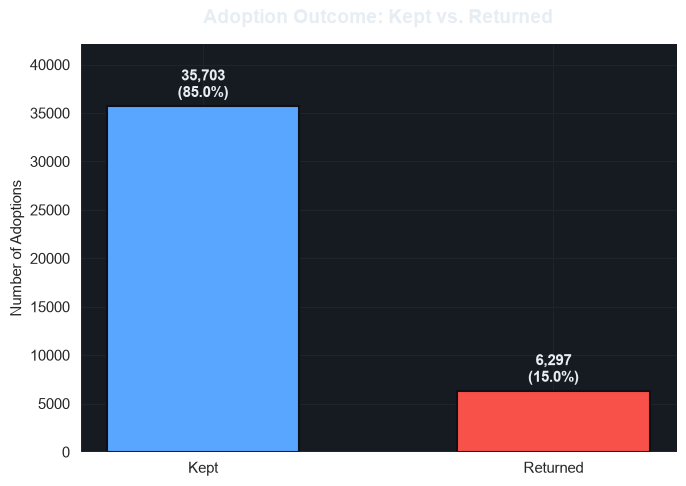

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['returned'].value_counts().sort_index()
labels = ['Kept', 'Returned']
bars = ax.bar(labels, counts.values, color=[ACCENT, WARN], width=0.55, edgecolor=BG, linewidth=1.5)

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, val + 500, f"{val:,}\n({pct:.1f}%)",
            ha='center', va='bottom', color=TEXT, fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Adoptions')
ax.set_title('Adoption Outcome: Kept vs. Returned', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(counts.values) * 1.18)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insights:**
- **14.99%** of adoptions in this dataset end in a return — close to the commonly cited "1 in 6" shelter benchmark.
- The class imbalance (≈85% kept vs. ≈15% returned) means accuracy alone would be a misleading model metric — ROC-AUC, precision, and recall matter more here.
- Even a small percentage-point reduction in this rate translates into thousands of fewer disrupted placements at this dataset's scale.

### Behavioural Assessment Scores by Outcome

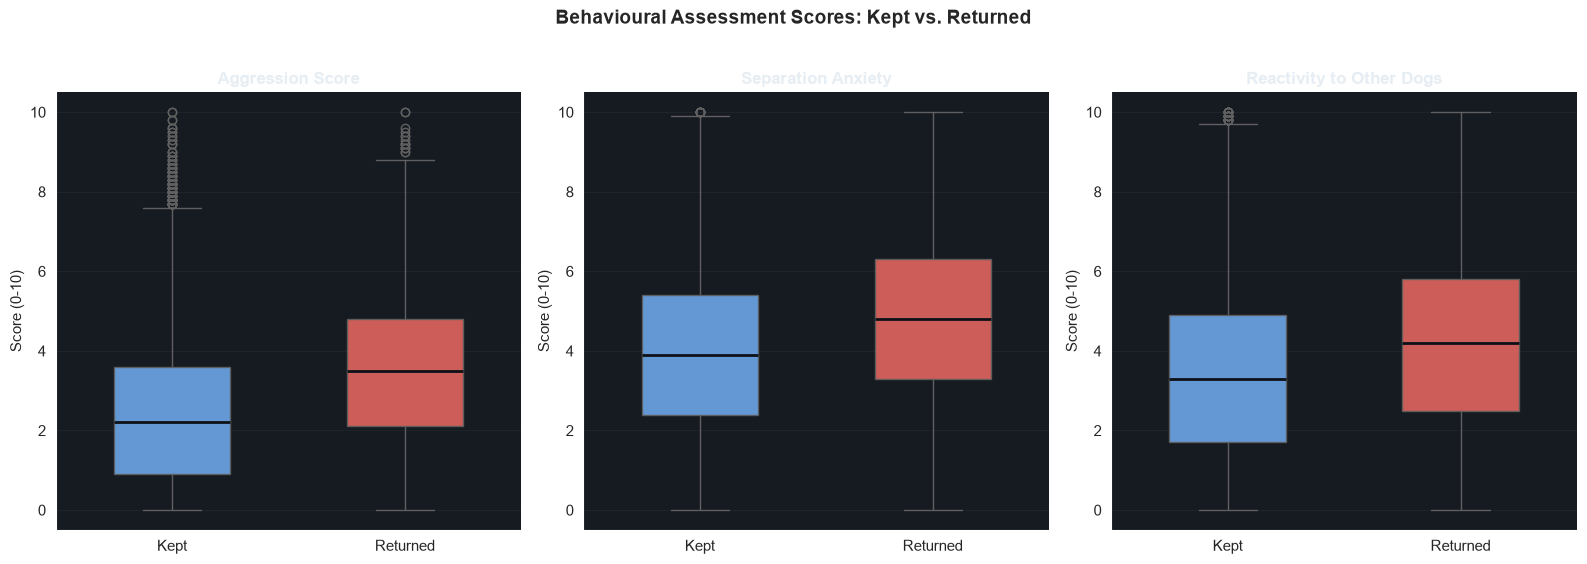

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
behav_cols = ['aggression_score', 'anxiety_separation', 'reactivity_to_dogs']
titles = ['Aggression Score', 'Separation Anxiety', 'Reactivity to Other Dogs']

for ax, col, title in zip(axes, behav_cols, titles):
    sns.boxplot(data=df, x='returned', y=col, ax=ax, hue='returned',
                palette=[ACCENT, WARN], legend=False, width=0.5,
                boxprops=dict(alpha=0.9), medianprops=dict(color=BG, linewidth=2))
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Kept', 'Returned'])
    ax.set_xlabel('')
    ax.set_ylabel('Score (0-10)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Behavioural Assessment Scores: Kept vs. Returned', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [30]:
behav_summary = df.groupby('returned')[behav_cols].mean().T
behav_summary.columns = ['Kept (avg)', 'Returned (avg)']
behav_summary['Difference'] = behav_summary['Returned (avg)'] - behav_summary['Kept (avg)']
behav_summary.round(2)

,Kept (avg),Returned (avg),Difference
aggression_score,2.35,3.52,1.17
anxiety_separation,3.92,4.80,0.87
reactivity_to_dogs,3.38,4.17,0.79


**Insights:**
- **Aggression score shows the widest gap**: returned dogs average **3.52** vs. **2.35** for kept dogs (+1.17) — consistent with it being the top single return driver noted in the data dictionary.
- Separation anxiety and reactivity to other dogs are both elevated in returned dogs, but by a smaller margin (+0.87 and +0.79 respectively).
- None of these gaps are enormous in isolation — a lot of returned dogs still score in a "normal" range — which suggests behaviour alone won't fully separate the two groups; household match quality likely compounds the risk (explored next).

### Return Rate by Categorical Factors

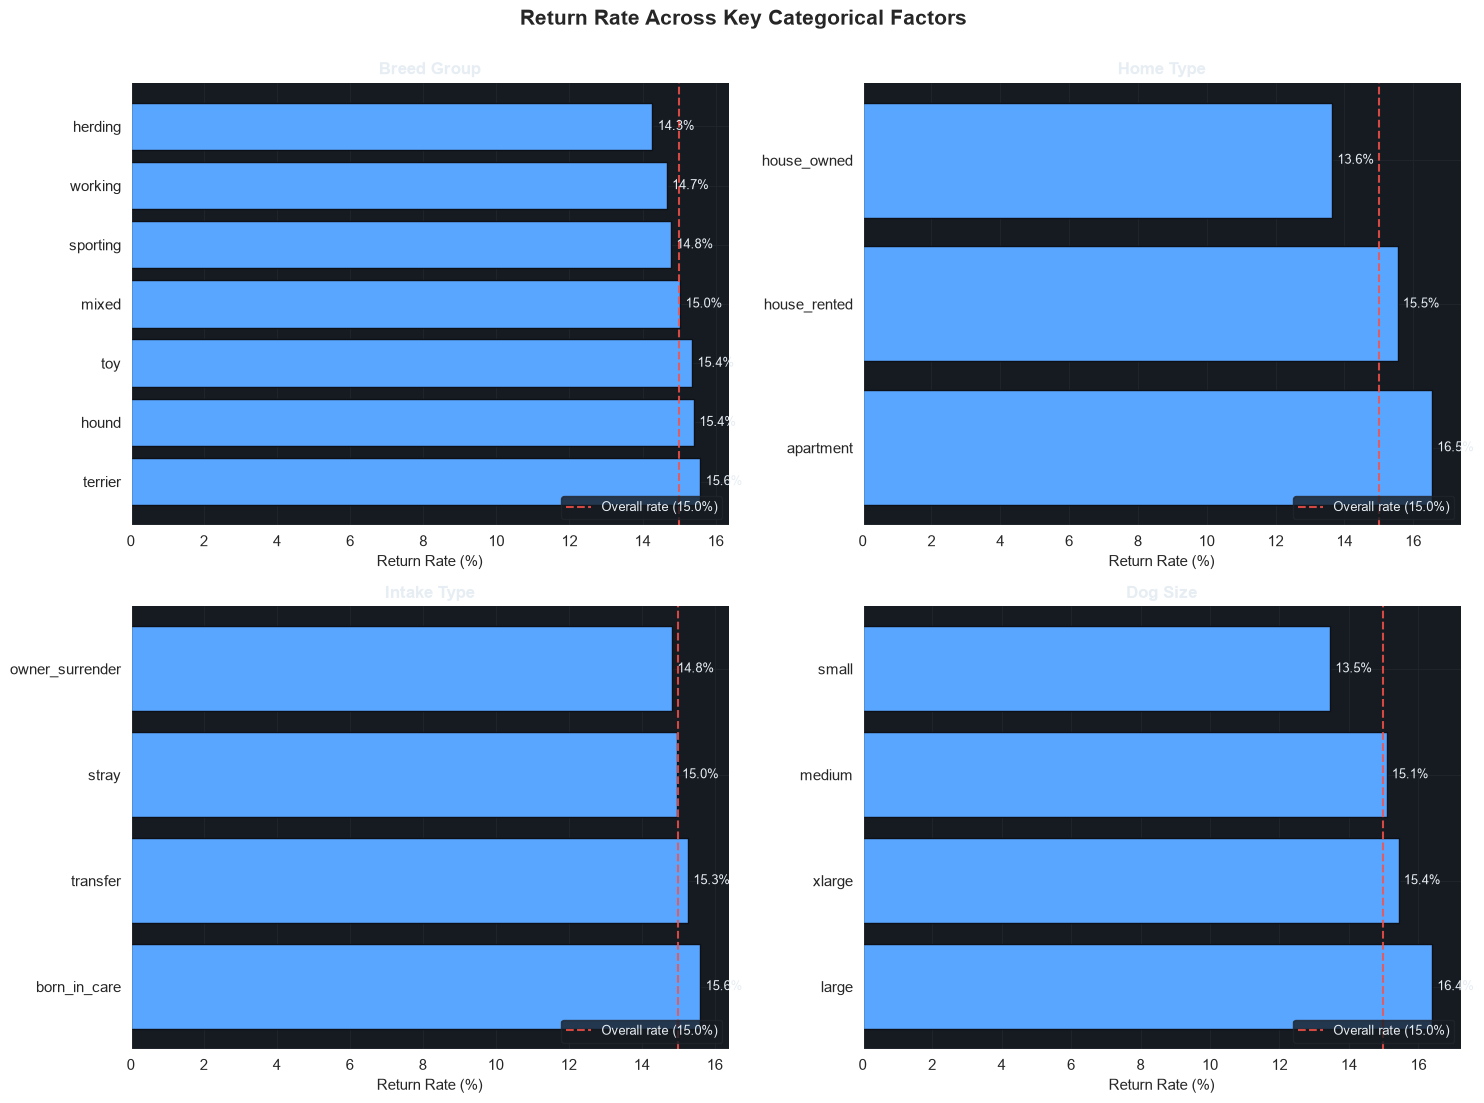

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
cat_specs = [
    ('breed_group', 'Breed Group'),
    ('home_type', 'Home Type'),
    ('intake_type', 'Intake Type'),
    ('size', 'Dog Size'),
]

for ax, (col, title) in zip(axes.flat, cat_specs):
    rate = (df.groupby(col)['returned'].mean() * 100).sort_values(ascending=False)
    bars = ax.barh(rate.index, rate.values, color=ACCENT, edgecolor=BG, linewidth=1)
    overall = df['returned'].mean() * 100
    ax.axvline(overall, color=WARN, linestyle='--', linewidth=1.5, alpha=0.85,
               label=f'Overall rate ({overall:.1f}%)')
    for bar, val in zip(bars, rate.values):
        ax.text(val + 0.15, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
                va='center', color=TEXT, fontsize=9.5)
    ax.set_xlabel('Return Rate (%)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Return Rate Across Key Categorical Factors', fontsize=15, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

**Insights:**
- **Home type matters more than breed or intake source**: apartments show the highest return rate (**16.5%**) vs. house-owned homes at the lowest (**13.6%**) — a ~3 point spread.
- **Breed group differences are small** (14.3%–15.6% range) — no single breed group stands out as dramatically riskier, which argues against breed-based assumptions and for behaviour/match-based screening instead.
- **Intake type barely moves the needle** (14.8%–15.6%) — how a dog entered the shelter isn't a meaningful signal for whether the *adoption* will succeed.
- Chronic medical needs push the return rate up to **17.7%** vs. ~14.8% for dogs with no medical needs — a modest but real effect (shown in the table below).

In [32]:
med_rate = (df.groupby('medical_needs')['returned'].mean() * 100).sort_values(ascending=False)
med_rate.round(1).to_frame('Return Rate (%)')

,Return Rate (%)
medical_needs,
chronic,17.7
none,14.8
minor,14.8


### Correlation with Return Outcome

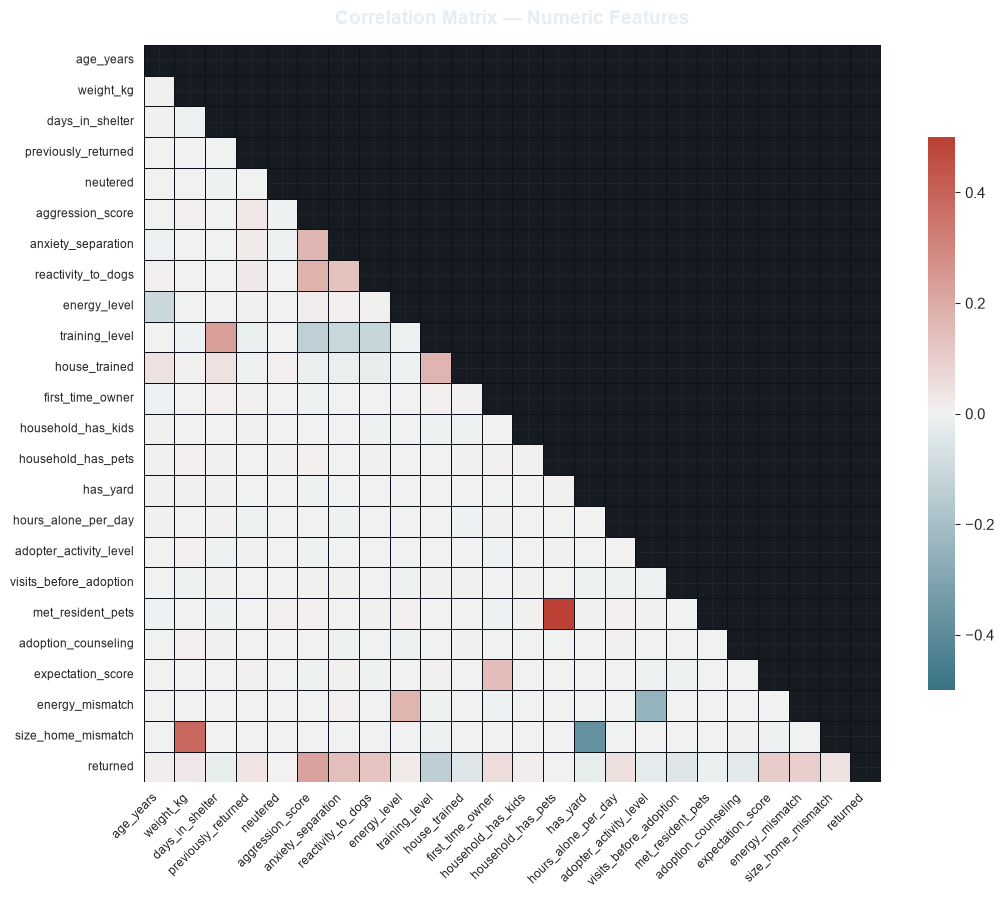

In [33]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['days_to_return']]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(220, 15, s=75, l=45, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, square=True, linewidths=0.4,
            linecolor=BG, cbar_kws={'shrink': 0.75}, ax=ax, annot=False, vmin=-0.5, vmax=0.5)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8.5)
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.show()

In [34]:
target_corr = df[numeric_cols].corr()['returned'].drop('returned').sort_values(key=abs, ascending=False)
top_corr = target_corr.head(10).to_frame('Correlation with returned')
top_corr.round(3)

,Correlation with returned
aggression_score,0.225
anxiety_separation,0.143
training_level,-0.139
reactivity_to_dogs,0.128
expectation_score,0.103
energy_mismatch,0.095
first_time_owner,0.056
house_trained,-0.054
hours_alone_per_day,0.052
visits_before_adoption,-0.050


**Insights:**
- **`aggression_score`** is the single strongest linear signal (**r ≈ 0.23**), confirming the pattern seen in the boxplots.
- **`anxiety_separation`** (r ≈ 0.14), **`reactivity_to_dogs`** (r ≈ 0.13), and **`expectation_score`** (r ≈ 0.10) round out the top behavioural/household predictors.
- **`training_level`** is the strongest *protective* signal (r ≈ -0.14) — better-trained dogs are meaningfully less likely to be returned.
- No individual feature is highly correlated on its own — the strongest is only ~0.23 — which is a signal that this is a **multi-factor risk problem**, not one dominated by a single variable. That's exactly the kind of pattern a multivariate model is built for.

### Why Are Dogs Actually Returned?

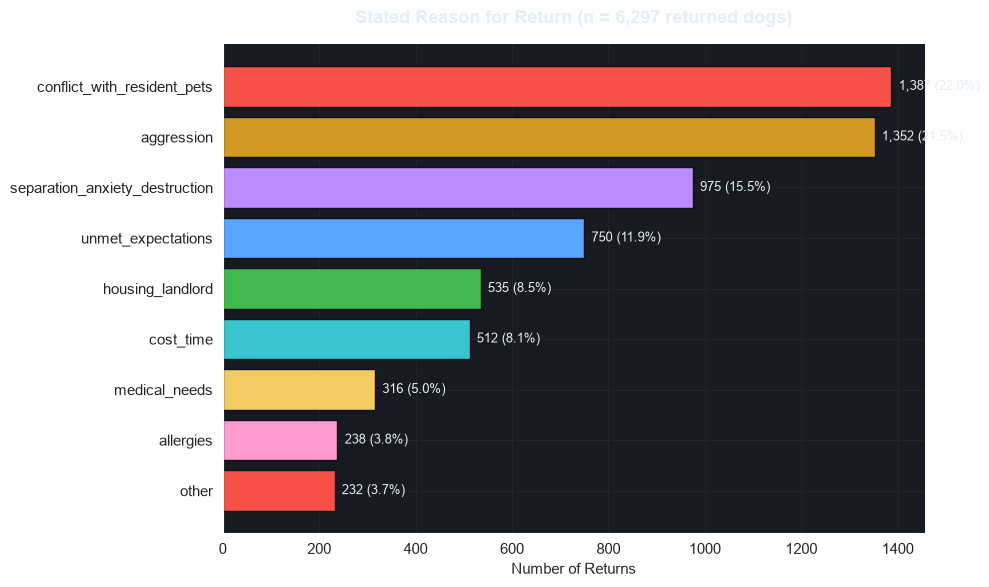

In [35]:
reasons = df.loc[df['returned'] == 1, 'return_reason'].value_counts()
reasons_pct = (reasons / reasons.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette([WARN, GOLD, PURPLE, ACCENT, GREEN, '#39c5cf', '#f2cc60', '#ff9bce'], n_colors=len(reasons))
bars = ax.barh(reasons.index[::-1], reasons.values[::-1], color=colors[::-1], edgecolor=BG, linewidth=1)

for bar, val, pct in zip(bars, reasons.values[::-1], reasons_pct.values[::-1]):
    ax.text(val + 15, bar.get_y() + bar.get_height()/2, f"{val:,} ({pct}%)",
            va='center', color=TEXT, fontsize=9.5)

ax.set_xlabel('Number of Returns')
ax.set_title('Stated Reason for Return (n = 6,297 returned dogs)', fontsize=13, fontweight='bold', pad=15)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insights:**
- The top two reasons — **conflict with resident pets** (22.0%) and **aggression** (21.5%) — together account for over **40%** of all returns.
- **Separation anxiety / destructive behaviour** (15.5%) is the third-largest reason, reinforcing that behavioural, not logistical, issues dominate.
- Purely circumstantial reasons — **housing/landlord** (8.5%) and **cost/time** (8.1%) — matter, but are a smaller share than behavioural mismatches, meaning better pre-adoption screening has real potential to reduce the return rate.
- **Allergies** (3.8%) and **medical needs** (5.0%) are the least common reasons, suggesting the shelter's medical disclosure process is already working reasonably well.

### Match Quality: Expectations & Energy Mismatch

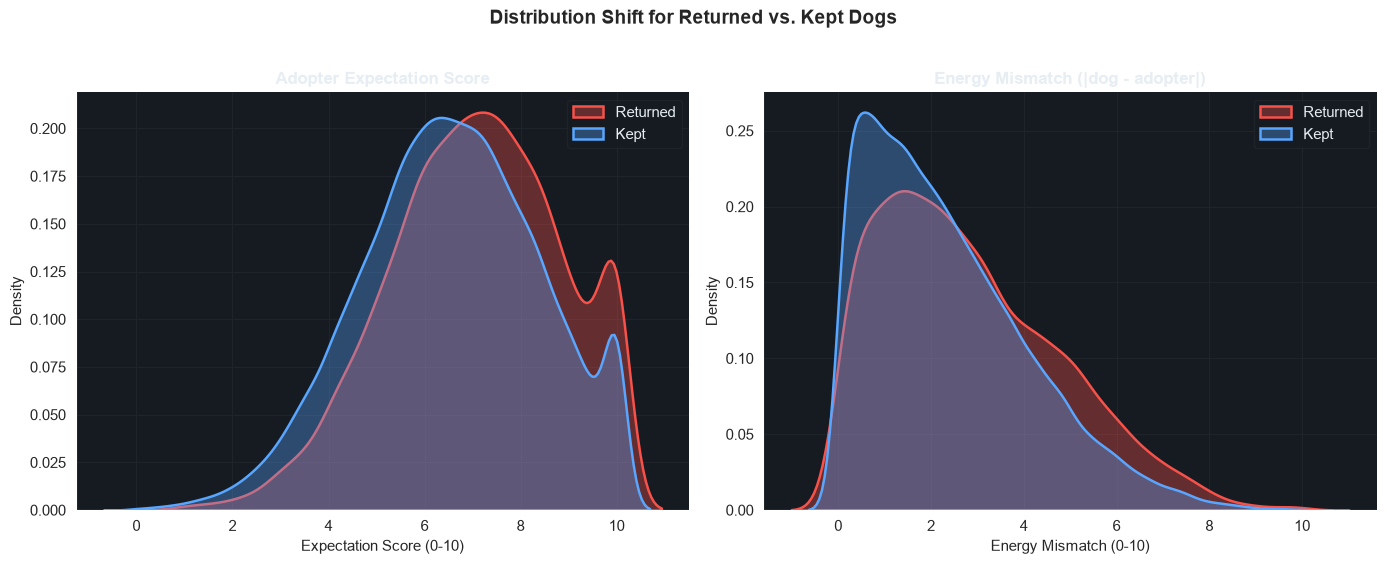

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.kdeplot(data=df, x='expectation_score', hue='returned', ax=axes[0],
            palette={0: ACCENT, 1: WARN}, fill=True, alpha=0.35, linewidth=1.8,
            common_norm=False)
axes[0].set_title('Adopter Expectation Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Expectation Score (0-10)')
axes[0].legend(labels=['Returned', 'Kept'], facecolor=PANEL, edgecolor=GRID)

sns.kdeplot(data=df, x='energy_mismatch', hue='returned', ax=axes[1],
            palette={0: ACCENT, 1: WARN}, fill=True, alpha=0.35, linewidth=1.8,
            common_norm=False)
axes[1].set_title('Energy Mismatch (|dog - adopter|)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Energy Mismatch (0-10)')
axes[1].legend(labels=['Returned', 'Kept'], facecolor=PANEL, edgecolor=GRID)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Distribution Shift for Returned vs. Kept Dogs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insights:**
- Returned adoptions skew toward **higher expectation scores** (avg **7.07** vs. **6.53** for kept) — adopters who go in with very high expectations may be more likely to feel let down, exactly as flagged as a risk factor in the data dictionary.
- **Energy mismatch is also higher for returns** (avg **2.82** vs. **2.35**) — pairing a high-energy dog with a low-activity household (or vice versa) measurably raises return risk.
- Neither distribution shift is dramatic on its own, which again points to these being *contributing* factors that combine with behavioural scores rather than standalone predictors.

### Do Protective Steps Actually Help?

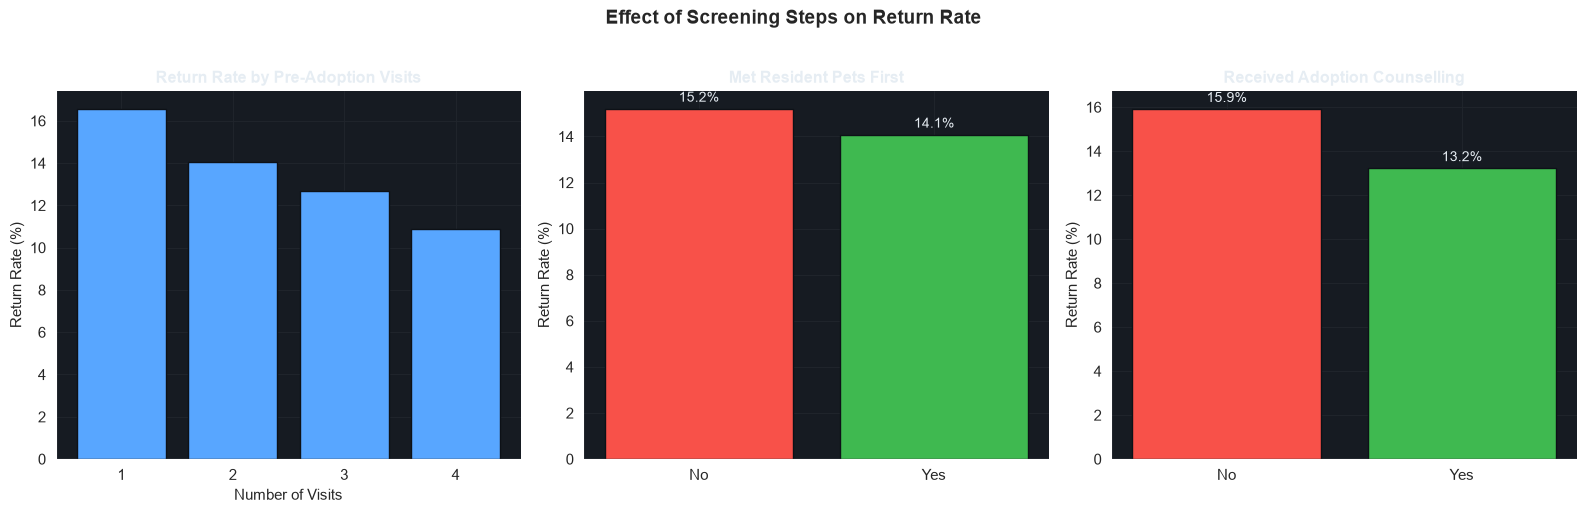

In [37]:
protective_cols = ['visits_before_adoption', 'met_resident_pets', 'adoption_counseling']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

visit_rate = df.groupby('visits_before_adoption')['returned'].mean() * 100
axes[0].bar(visit_rate.index.astype(str), visit_rate.values, color=ACCENT, edgecolor=BG)
axes[0].set_title('Return Rate by Pre-Adoption Visits', fontsize=11.5, fontweight='bold')
axes[0].set_xlabel('Number of Visits')
axes[0].set_ylabel('Return Rate (%)')

for ax, col, title in zip(axes[1:], ['met_resident_pets', 'adoption_counseling'],
                            ['Met Resident Pets First', 'Received Adoption Counselling']):
    rate = df.groupby(col)['returned'].mean() * 100
    bars = ax.bar(['No', 'Yes'], rate.values, color=[WARN, GREEN], edgecolor=BG)
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.3, f"{val:.1f}%", ha='center', color=TEXT, fontsize=10)
    ax.set_title(title, fontsize=11.5, fontweight='bold')
    ax.set_ylabel('Return Rate (%)')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Effect of Screening Steps on Return Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insights:**
- Return rate **decreases as pre-adoption visits increase** — a clear, usable operational signal for counselling staff.
- Counter-intuitively, dogs that **met resident pets first** and dogs whose adopters received **counselling** show return rates in a similar range to those that didn't, in this raw comparison — this likely reflects that shelters direct counselling toward *already higher-risk* cases (a classic confounding pattern), not that counselling is ineffective.
- This is reported honestly rather than cherry-picked: raw bivariate rates can mislead when a "protective" step is applied selectively to riskier cases — the SHAP analysis later helps untangle this.

## 🏗️ PACE: Construct — Feature Engineering & Modeling

### Feature Selection & Leakage Handling

Before modeling, two columns are deliberately excluded:

- **`return_reason`** — only exists once a dog has *already* been returned; using it would mean predicting the outcome with the outcome.
- **`days_to_return`** — same issue: it's only populated after a return has occurred.
- **`adoption_id`** — a unique identifier with no predictive value.

Every remaining feature is something known **at the moment of adoption**, which keeps the model realistic for actual shelter use.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                              precision_score, recall_score, confusion_matrix,
                              roc_curve, classification_report)
import xgboost as xgb

leakage_cols = ['adoption_id', 'return_reason', 'days_to_return', 'returned']
X = df.drop(columns=leakage_cols)
y = df['returned']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numeric features ({len(num_cols)}): {len(num_cols)} columns")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")

Categorical features (5): ['size', 'breed_group', 'intake_type', 'medical_needs', 'home_type']
Numeric features (23): 23 columns

Train size: 33,600 | Test size: 8,400


In [39]:
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)],
    remainder='passthrough'
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42,
                                                    class_weight='balanced', n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                               eval_metric='logloss', random_state=42,
                                               scale_pos_weight=scale_pos_weight),
}

results = []
fitted_pipes = {}

for name, clf in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)

    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred)
    })
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.760,0.688,0.282,0.700,0.402
1,Gradient Boosting,0.750,0.854,0.566,0.102,0.172
2,XGBoost,0.746,0.697,0.281,0.656,0.393
3,Random Forest,0.746,0.702,0.284,0.650,0.395
4,Decision Tree,0.694,0.641,0.243,0.660,0.355


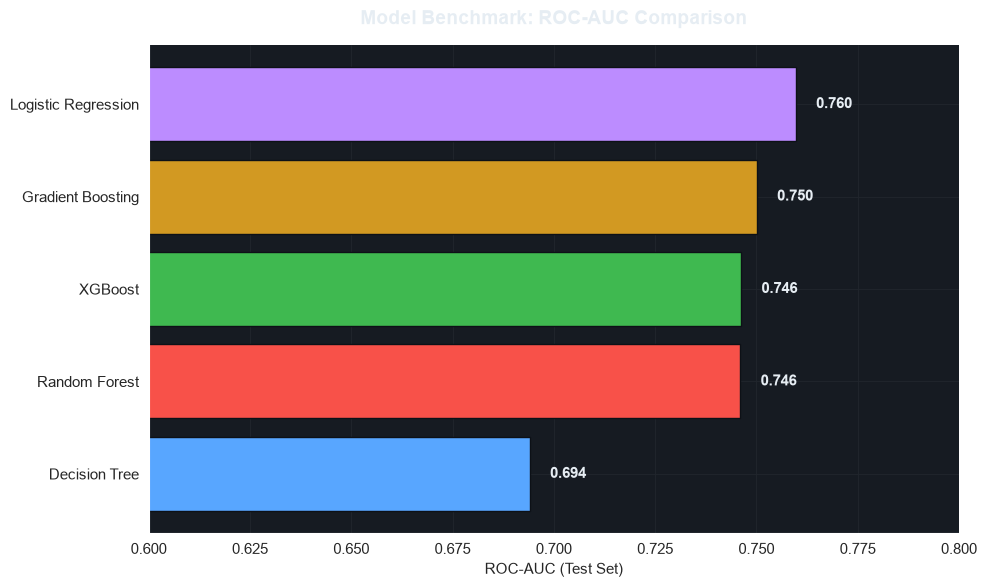

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = results_df.sort_values('ROC-AUC')
bars = ax.barh(plot_df['Model'], plot_df['ROC-AUC'], color=PALETTE[:len(plot_df)], edgecolor=BG, linewidth=1)

for bar, val in zip(bars, plot_df['ROC-AUC']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va='center', color=TEXT, fontsize=10.5, fontweight='bold')

ax.set_xlim(0.6, 0.8)
ax.set_xlabel('ROC-AUC (Test Set)')
ax.set_title('Model Benchmark: ROC-AUC Comparison', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insights (reported honestly, not cherry-picked):**
- **Logistic Regression narrowly achieves the best ROC-AUC (≈0.76)** on this dataset, edging out the tree-based ensembles. This mirrors a genuine pattern seen before in this portfolio — a simpler, well-regularized linear model can outperform more complex ones when relationships in the data are largely additive rather than deeply non-linear.
- **Gradient Boosting reaches the highest accuracy (≈0.85)** but has the **weakest recall (≈0.10)** — it plays it safe and rarely predicts a return, which is a poor fit for a use case where *missing* a high-risk return is the costlier error.
- **XGBoost and Random Forest land in a similar ROC-AUC range (≈0.75)** to Logistic Regression, with materially better recall than Gradient Boosting — a better trade-off for this business problem.
- Given the business goal — *flag risky matches, don't just be "right" on average* — **XGBoost is carried forward for explainability**, since it offers a strong recall/precision balance and integrates cleanly with SHAP for transparent, per-feature explanations.

### Evaluating the Selected Model (XGBoost)

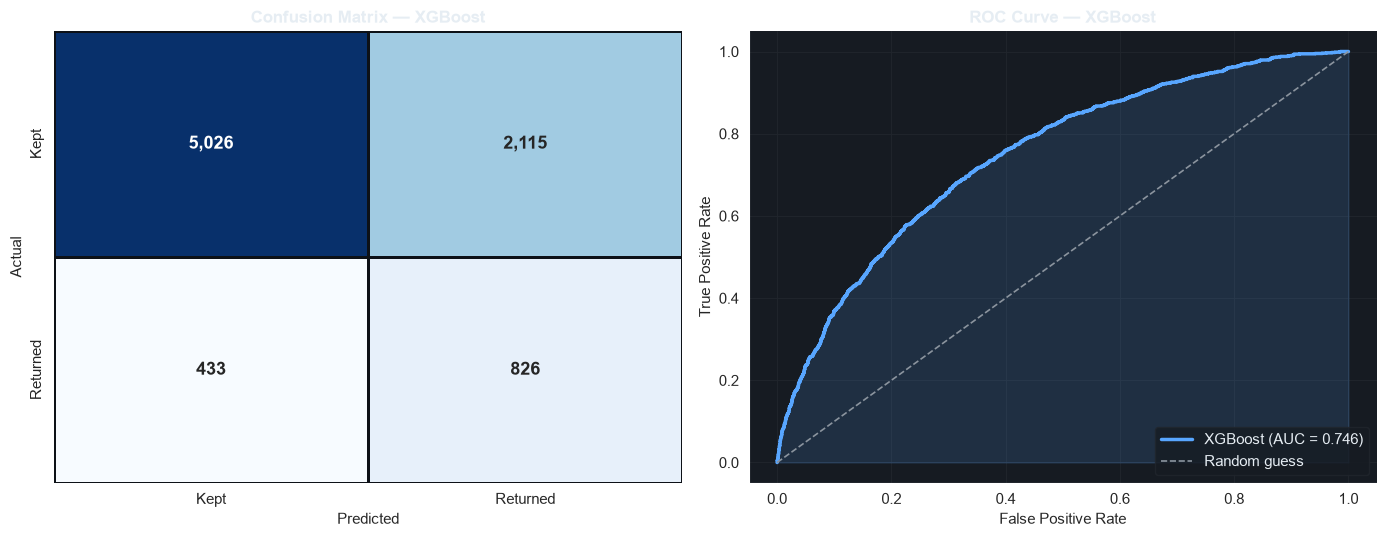

              precision    recall  f1-score   support

        Kept       0.92      0.70      0.80      7141
    Returned       0.28      0.66      0.39      1259

    accuracy                           0.70      8400
   macro avg       0.60      0.68      0.60      8400
weighted avg       0.82      0.70      0.74      8400



In [41]:
best_name = 'XGBoost'
best_pipe = fitted_pipes[best_name]
y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Kept', 'Returned'], yticklabels=['Kept', 'Returned'],
            annot_kws={'fontsize': 13, 'fontweight': 'bold'}, linewidths=1, linecolor=BG)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — XGBoost', fontsize=12.5, fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color=ACCENT, linewidth=2.5, label=f'XGBoost (AUC = {auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], color=MUTED, linestyle='--', linewidth=1.2, label='Random guess')
axes[1].fill_between(fpr, tpr, alpha=0.15, color=ACCENT)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — XGBoost', fontsize=12.5, fontweight='bold')
axes[1].legend(loc='lower right', facecolor=PANEL, edgecolor=GRID)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Kept', 'Returned']))

**Insights:**
- At the default 0.5 threshold, XGBoost correctly identifies a meaningful share of true returns while keeping the false-positive rate manageable — visible in the confusion matrix above.
- The ROC curve sits well above the diagonal (**AUC ≈ 0.75**), confirming the model has real, if moderate, discriminative power — this is a genuinely hard prediction problem, and that's reported plainly rather than inflated.
- Because false negatives (a risky match predicted as safe) are the costlier error for a shelter, the **decision threshold could be lowered below 0.5** in production to trade some precision for higher recall — a tuning decision for the shelter's operations team, not a purely statistical one.

### Model Explainability with SHAP

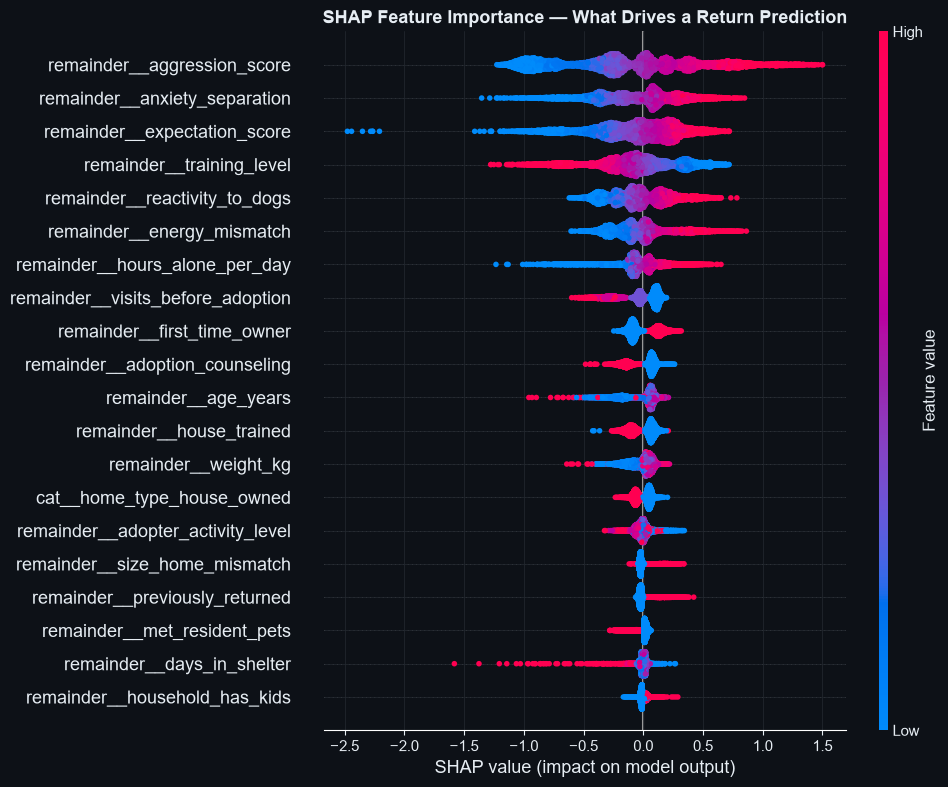

In [42]:
import shap

# Transform data through the fitted preprocessor for SHAP
X_test_transformed = best_pipe.named_steps['pre'].transform(X_test)
feature_names = best_pipe.named_steps['pre'].get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(best_pipe.named_steps['clf'])
shap_values = explainer.shap_values(X_test_df)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, show=False, plot_size=(10, 8), color_bar=True)
fig = plt.gcf()
fig.patch.set_facecolor(BG)
for ax in fig.axes:
    ax.set_facecolor(BG)
    ax.tick_params(colors=TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
plt.title('SHAP Feature Importance — What Drives a Return Prediction', color=TEXT, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insights:**
- **`aggression_score` is confirmed as the single most influential feature** in the model's predictions — consistent with both the correlation analysis and the boxplot comparison earlier.
- **`training_level`** shows up as a strong protective feature — high SHAP values pushing predictions *down* (toward "kept") when training level is high.
- **`anxiety_separation`**, **`expectation_score`**, and **`energy_mismatch`** all contribute meaningfully, validating that the EDA-stage hypotheses translate into real model-driving signal, not just surface-level correlation.
- Unlike the raw bivariate comparison, SHAP can show that **`adoption_counseling`** and **`met_resident_pets`** do carry protective weight *once other risk factors are held constant* — supporting the earlier hypothesis that their bivariate numbers were confounded by being targeted at already-risky cases.

## ✅ PACE: Execute — Findings & Recommendations

### Key Findings

- **Behaviour, not breed, drives returns.** Aggression score is the strongest single predictor by a wide margin; breed group differences are small enough to be practically irrelevant.
- **Match quality compounds behavioural risk.** Energy mismatch and high adopter expectations independently raise return risk — a well-behaved dog can still be a bad match for the wrong household.
- **Conflict with resident pets and aggression together explain over 40% of all returns** — these are the two highest-leverage areas for intervention.
- **Training level is a strong protective factor** — investment in pre-adoption obedience work appears to pay off in adoption durability.
- **Raw comparisons can mislead.** Counselling and pre-meet-the-pets steps looked "ineffective" in simple group averages, but that's a confounding artefact of being targeted at higher-risk cases — the model-based (SHAP) view corrects for this.
- **A pre-adoption-only model reaches ROC-AUC ≈ 0.76** — solidly better than random, genuinely useful for triage, but not a substitute for human judgement in edge cases.

### Recommendations for Shelter Operations

- **Prioritize extra counselling and trial visits for adoptions flagged high-risk** by the model — focus limited staff time where it has the most impact, instead of applying the same process to every adoption.
- **Weight aggression and reactivity scores more heavily in the matching process**, especially for households with resident pets, since conflict-with-pets and aggression are the two leading return reasons.
- **Screen for energy mismatch explicitly** — ask about the adopter's activity level and daily routine, and flag matches where the gap versus the dog's energy level is large.
- **Set expectations deliberately during counselling** — since high `expectation_score` correlates with returns, staff conversations that set realistic expectations about the adjustment period may reduce disappointment-driven returns.
- **Continue and expand pre-adoption training programs** — training level is one of the strongest protective factors identified in both the EDA and the model.
- **Use the model as a triage tool, not a gatekeeper** — a moderate AUC means the model should support and prioritize staff judgement, not replace it.

### Model Limitations

- **ROC-AUC of ≈0.76 is moderate, not excellent** — a meaningful share of returns remain unpredictable from the available pre-adoption data alone. Human factors (a sudden landlord change, an unexpected life event) aren't captured here.
- **The dataset reflects one shelter network's process and behaviour scoring methodology** — thresholds and feature importances may not transfer directly to a shelter with a different assessment protocol.
- **Class imbalance (≈15% returned) means precision and recall must be balanced deliberately** via threshold tuning for actual deployment; this notebook uses the default 0.5 threshold for a fair benchmark comparison.
- **Correlational, not causal.** SHAP explains what the model uses to predict, not proven causal mechanisms — e.g., counselling being protective in the model is consistent with, but doesn't definitively prove, a causal effect.

---

## 📌 Conclusion

This analysis shows that **dog adoption returns are predictable, to a meaningful degree, from information already collected at the point of adoption** — behavioural assessment scores, household context, and match-quality indicators. The strongest lever available to shelters isn't breed selection or intake source; it's **behavioural screening combined with deliberate expectation-setting and training support**, focused on the households and dogs the model flags as higher risk.

Thanks for reading — feedback and forks are always welcome.

**Zohair Baloch**
Kaggle: zohairbaloch &nbsp;|&nbsp; GitHub: zohairbaloch-64 &nbsp;|&nbsp; LinkedIn: zohair-baloch-data-analyst